# Test — Cell Lattice + PINNs


In [1]:
import numpy as np
from dyn_modelling.models.cell_lattice import build_lattice, simulate_cell_lattice, compute_distance_matrix, compute_weights, compute_rhs, external_signal
from dyn_modelling.methods.pinn import ANN, init_params, make_pinn, train
from dyn_modelling.utils.plots import plot_graph, plot_trajectories, plot_loss, plot_parameter_evolution, plot_predictions
from dyn_modelling.utils.data import add_noise
import jax
import jax.numpy as jnp

## 1. Build the lattice


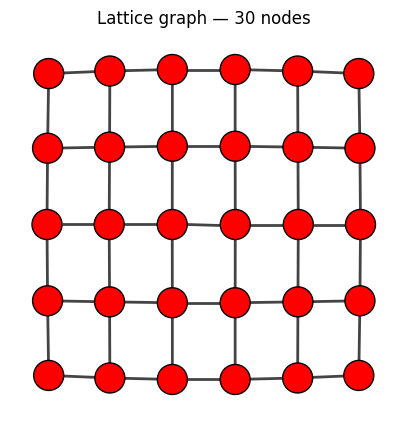

In [2]:
rows, cols = 5, 6
N = rows * cols

g = build_lattice(rows, cols)
plot_graph(g)

## 2. Simulate cell lattice


In [3]:
# Parameters
a_params = np.array([2.4, 3.5, 2.0, 1.0])
l_params = np.array([1.0, 1.0, 0.2])
t_on, t_off = 80.0, 500.0
t_end, n_steps = 500.0, 100
neigh_order = 2

# Build RHS
dist_matrix = compute_distance_matrix(g)
rhs = compute_rhs(g, dist_matrix, l_params, neigh_order, t_on, t_off, a_params=a_params)


# Initial conditions
np.random.seed(1)
x0 = np.random.rand(N * 3)
t_eval = np.linspace(0, t_end, n_steps)

# Simulate
y = simulate_cell_lattice(rhs, x0, (0, t_end), t_eval)

## 3. Plot trajectories — clean data


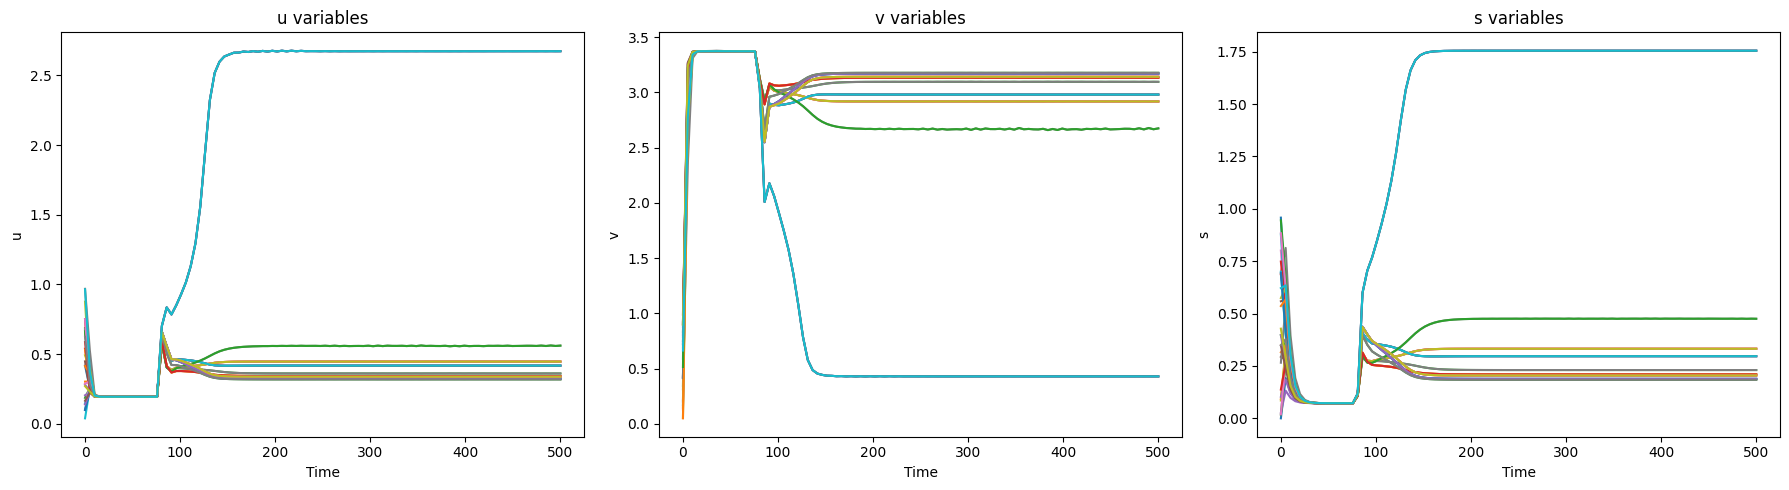

In [4]:
plot_trajectories(t_eval, y)

## 4. Plot trajectories — noisy data


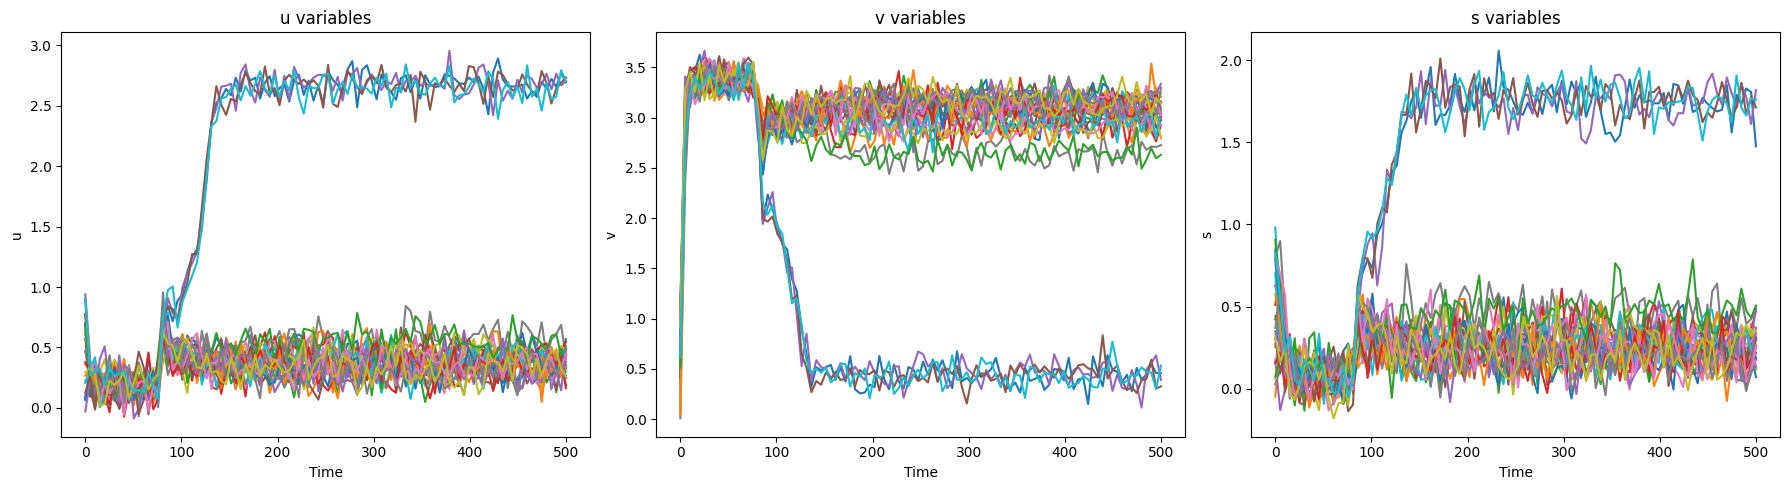

In [5]:
y_noisy = add_noise(y, noise_level=0.1)
plot_trajectories(t_eval, y_noisy)

## 5. Prepare data for PINN


In [6]:
T = t_eval[:, None]       # (100, 1)
Y = y.T                   # (100, 3*N) clean
#Y_noisy = y_noisy.T       # (100, 3*N) noisy

## 6. Train PINN


In [7]:
# Build PINN
rhs = compute_rhs(g, dist_matrix, l_params, neigh_order, t_on, t_off)
batch_loss, grad_fn = make_pinn(rhs)

# Initialize ANN and model parameters
topology = [1, 64, 64, 64, 64, 3 * N]
ann_params = init_params(topology)
a_init = np.ones(4)
a_true = a_params.copy()

# Train
ann_params, a_list, loss_history = train(
    ann_params, a_init, T, Y,
    batch_loss, grad_fn,
    lmbd=0.4, n_epochs=50000,
    lr_ann=1e-4, lr_model=1e-2, momentum=0.9
)

[     0] loss = 134.232162 | a = [0.36153322 0.65560585 0.99996585 0.43550414]
[  5000] loss = 1.007965 | a = [2.8870196 3.4607759 1.8646449 0.4668917]
[ 10000] loss = 0.386991 | a = [2.3067532 3.4931    2.0042183 0.9782159]
[ 15000] loss = 0.272848 | a = [2.3307316 3.4952033 2.0050464 0.9874947]
[ 20000] loss = 0.211643 | a = [2.2880952 3.4977782 2.0073407 1.0505553]
[ 25000] loss = 0.176695 | a = [2.2691333 3.4993598 2.0094757 1.0801735]
[ 30000] loss = 0.154109 | a = [2.273728  3.500103  2.0107207 1.0816197]
[ 35000] loss = 0.135993 | a = [2.297078  3.5003042 2.010649  1.0628018]
[ 40000] loss = 0.119308 | a = [2.3349392 3.5000165 2.0088968 1.0290428]
[ 45000] loss = 0.104027 | a = [2.3807123 3.4993217 2.0056381 0.9873065]


## 7. Plot loss


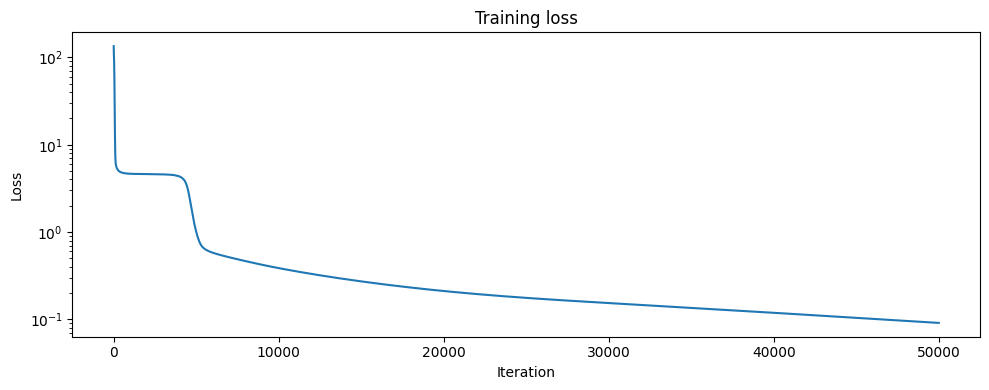

In [8]:
plot_loss(loss_history)

## 8. Plot parameter evolution


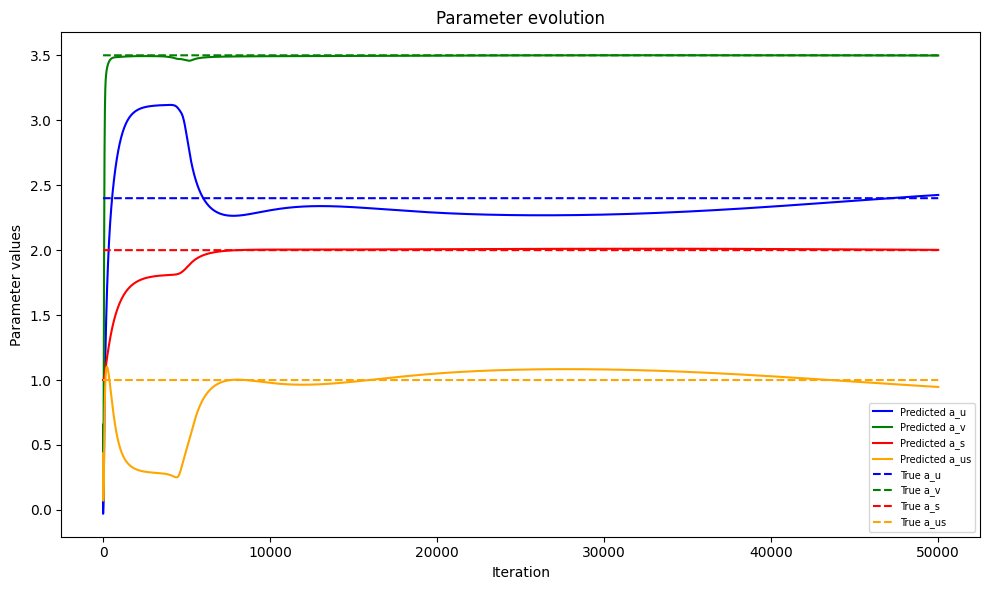

In [9]:
plot_parameter_evolution(a_list, a_true)

## 9. Plot predicted vs true trajectories


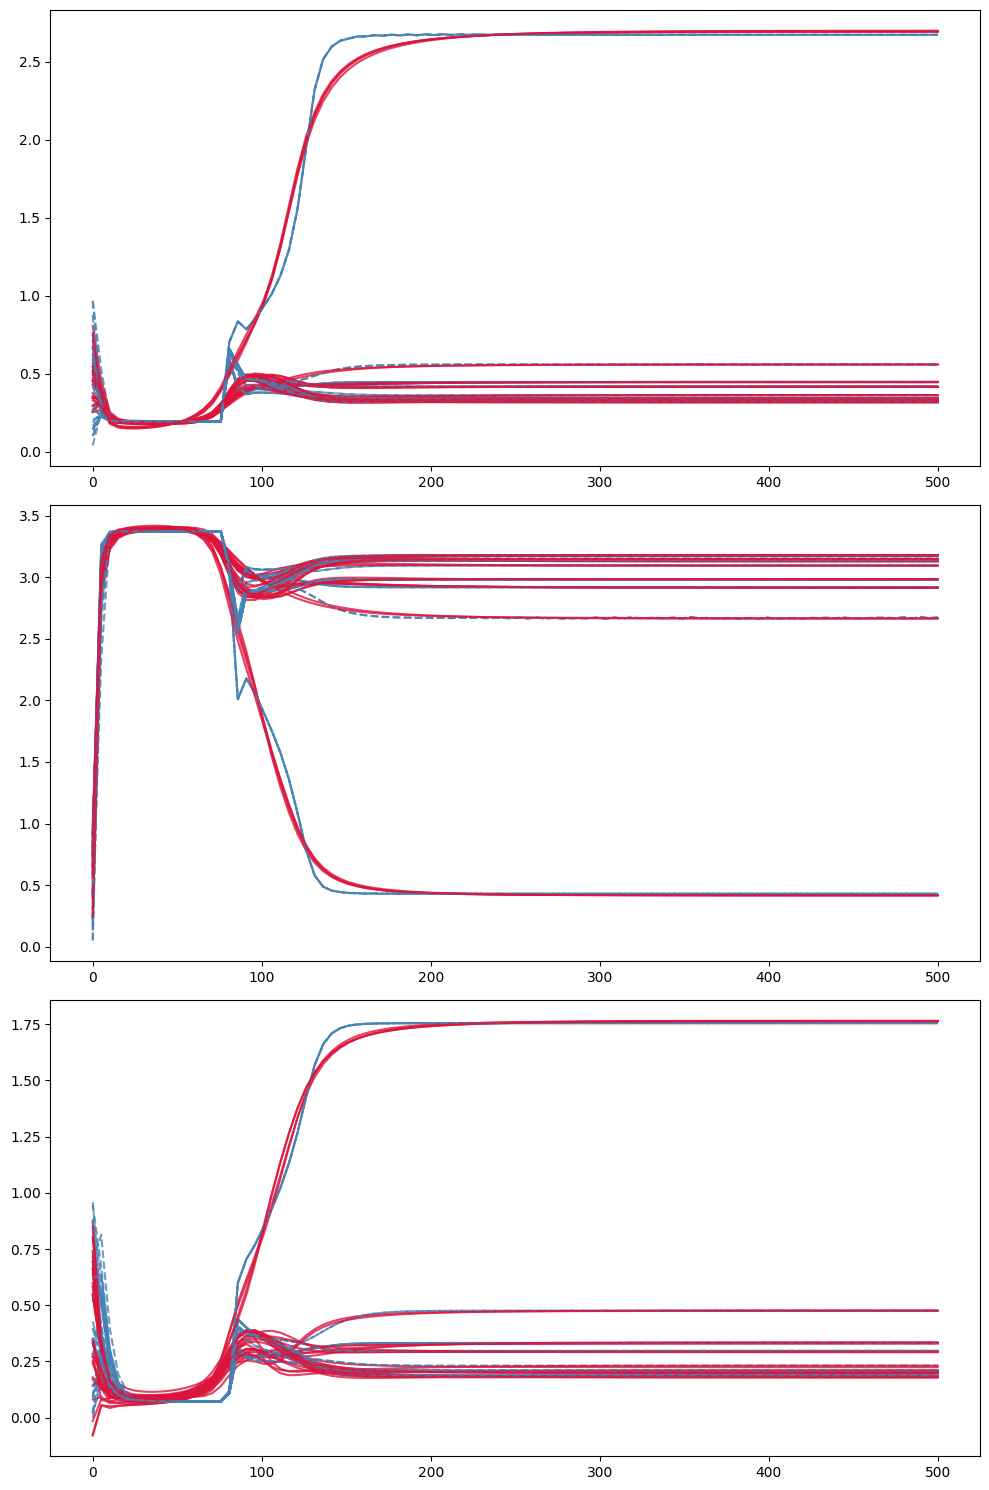

In [10]:
batch_ANN = jax.vmap(lambda t: ANN(ann_params, t))
y_pred = np.array(batch_ANN(T))   # (n_steps, 3*N)

plot_predictions(t_eval, y_pred, Y)

## 10. Final identified parameters


In [11]:
a_final = a_list[-1]
print(f'True parameters:      {a_true}')
print(f'Identified parameters: {a_final}')
print(f'Absolute error:        {np.abs(a_final - a_true)}')

True parameters:      [2.4 3.5 2.  1. ]
Identified parameters: [2.4249067 3.498437  2.0022194 0.9469091]
Absolute error:        [0.02490664 0.00156307 0.00221944 0.05309087]
